## 1. Introduction: Tree Height Raster Processing

In this notebook, we generate the final mask layer: **Higher Vegetation** (Trees and large bushes). 

**The Strategy:**
1. **Direct Raster Alignment:** We load the City of Zürich tree-height raster.
2. **Binary Transformation:** We apply a height threshold (e.g., > 2.0m) to distinguish trees from ground/grass.
3. **Global Resampling:** We resample the city-wide raster to match our target resolution (~0.19m/pixel) to ensure pixel-perfect alignment with SWISSIMAGE.
4. **Windowed Extraction:** We use our building anchors to slice out 512x512 patches.

In [28]:
import os
import math
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import from_bounds
import rasterio.plot
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# --- Directory Configuration ---
BASE_OUT = "../data/processed_modular"
META_DIR = f"{BASE_OUT}/metadata"
MASK_TASK_NAME = "masks_highveg"
GLOBAL_MASK_PATH = f"{META_DIR}/global_highveg_mask_2056.tif"
ANCHOR_PATH = f"{META_DIR}/building_anchors_2000.gpkg"

# TODO: Update to the path of your Zürich Tree Height TIF
#/Users/fadricampell/Documents/HSLU/Modules/Computer_Vision/urban-habitats-cv/new_pipeline/data/raw/vhm/data/baumhoehen_chm_2022.tif
TREE_HEIGHT_PATH = "../data/raw/vhm/data/baumhoehen_chm_2022.tif"

# --- Hyperparameters ---
CROP_RADIUS_M = 50 
IMG_SIZE = 512
TARGET_RES = 100.0 / 512.0  # ~0.1953m per pixel

# Threshold: Height in meters to be considered a "tree/high bush"
# Usually 2.0m is the standard for 'Higher Vegetation' in urban planning
MIN_HEIGHT_M = 2.0

## 2. Creating the Global High-Veg Mask

Instead of just copying the file, we perform two operations:
1. **Thresholding:** We convert the continuous height values (0m to 40m) into a binary `0` and `1`.
2. **Resampling:** We ensure the final global mask has the exact same pixel density as our aerial images.

In [10]:
if not os.path.exists(GLOBAL_MASK_PATH):
    print("Processing Tree Height Raster...")
    
    with rasterio.open(TREE_HEIGHT_PATH) as src:
        # Calculate new dimensions for our target resolution
        new_width = math.ceil((src.bounds.right - src.bounds.left) / TARGET_RES)
        new_height = math.ceil((src.bounds.top - src.bounds.bottom) / TARGET_RES)
        
        # New transform for the resampled grid
        new_transform = rasterio.transform.from_origin(
            src.bounds.left, src.bounds.top, TARGET_RES, TARGET_RES
        )
        
        # Read and resample simultaneously
        print(f"Resampling to {new_width}x{new_height}...")
        data = src.read(
            1,
            out_shape=(new_height, new_width),
            resampling=Resampling.nearest # Keep boundaries sharp for trees
        )
        
        # Apply binary threshold
        print(f"Applying threshold: height > {MIN_HEIGHT_M}m")
        global_mask = (data > MIN_HEIGHT_M).astype(np.uint8)
        
        # Save to metadata folder
        with rasterio.open(
            GLOBAL_MASK_PATH, 'w',
            driver='GTiff', height=new_height, width=new_width, count=1, 
            dtype=rasterio.uint8, crs=src.crs, transform=new_transform, compress='lzw'
        ) as ds:
            ds.write(global_mask, 1)
            
    print(f"✅ Global High-Veg mask saved: {GLOBAL_MASK_PATH}")
else:
    print(f"✅ Reusing existing global mask.")

Processing Tree Height Raster...
Resampling to 68818x65137...
Applying threshold: height > 2.0m
✅ Global High-Veg mask saved: ../data/processed_modular/metadata/global_highveg_mask_2056.tif


## 3. Visual Validation of the Global Raster

We plot the processed mask to ensure the city-wide "Tree Canopy" is correctly identified.

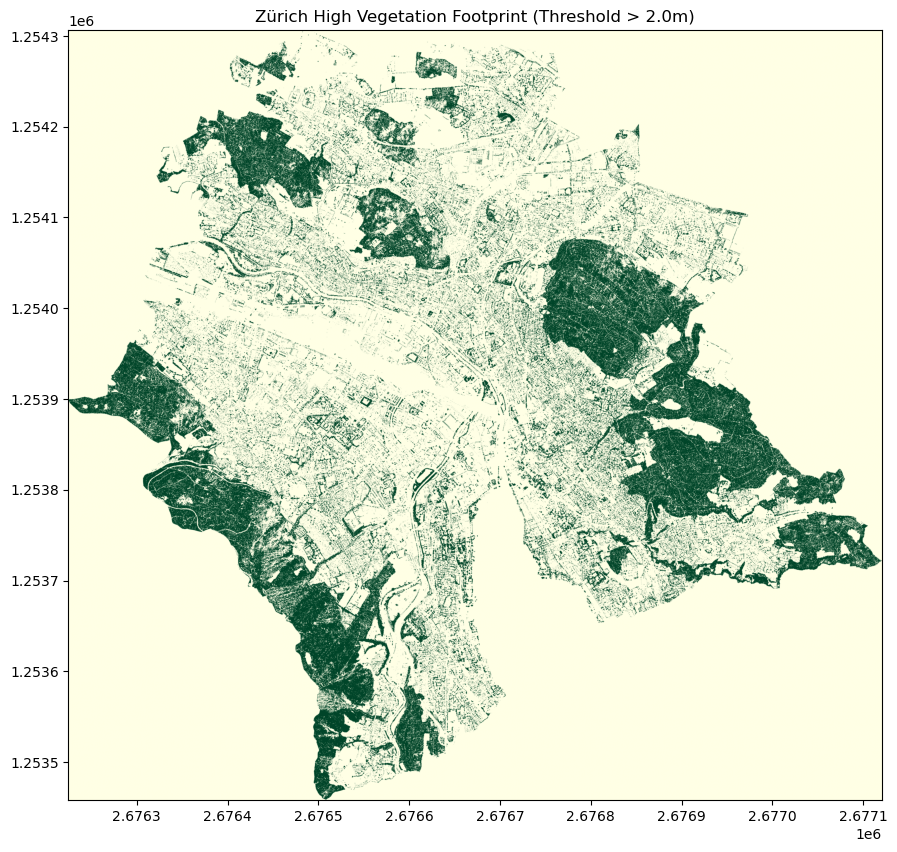

In [20]:
with rasterio.open(GLOBAL_MASK_PATH) as src:
    preview_factor = 15
    preview_data = src.read(1, out_shape=(src.height//preview_factor, src.width//preview_factor))
    
    fig, ax = plt.subplots(figsize=(12, 10))
    rasterio.plot.show(preview_data, transform=src.transform, ax=ax, cmap='YlGn')
    ax.set_title(f"Zürich High Vegetation Footprint (Threshold > {MIN_HEIGHT_M}m)")
    plt.show()

## 4. Extracting Patches for Training

We now use our building anchors to slice 512x512 patches from the processed global mask.

In [30]:
gdf_anchors = gpd.read_file(ANCHOR_PATH)

with rasterio.open(GLOBAL_MASK_PATH) as src_global:
    # 1. Store the global transform and bounds for fast access
    gt = src_global.transform
    gbounds = src_global.bounds
    
    for idx, row in tqdm(gdf_anchors.iterrows(), total=len(gdf_anchors)):
        uid, split = row['unique_id'], row['split']
        out_folder = f"{BASE_OUT}/{split}/{MASK_TASK_NAME}"
        os.makedirs(out_folder, exist_ok=True)
        out_path = f"{BASE_OUT}/{split}/{MASK_TASK_NAME}/{uid}_mask.tif"

        
        if os.path.exists(out_path): continue
        
        # 2. Define coordinates
        minx, maxx = row['x_2056'] - CROP_RADIUS_M, row['x_2056'] + CROP_RADIUS_M
        miny, maxy = row['y_2056'] - CROP_RADIUS_M, row['y_2056'] + CROP_RADIUS_M
        
        # 3. FIX A: Check if the anchor is actually inside the global bounds
        # If it's even 0.001m outside, boundless=True returns all zeros.
        if (minx < gbounds.left or maxx > gbounds.right or 
            miny < gbounds.bottom or maxy > gbounds.top):
            # This anchor is on the edge of your city-wide TIF
            is_edge = True
        else:
            is_edge = False

        # 4. FIX B: Use window.round() 
        # Floating point errors in 'from_bounds' can lead to "empty" reads.
        # Rounding forces the window to align with the nearest pixel grid.
        window = from_bounds(minx, miny, maxx, maxy, transform=gt).round()
        
        # 5. FIX C: Explicitly fetch the data
        # We use out_shape to force the 512x512 size regardless of window rounding
        mask_patch = src_global.read(
            1, 
            window=window, 
            boundless=True, 
            fill_value=0, 
            out_shape=(IMG_SIZE, IMG_SIZE)
        )
        
        # 6. Safety Check: If patch is empty, try reading without 'boundless' 
        # to see if it triggers an error (which helps us debug)
        if mask_patch.max() == 0 and not is_edge:
             # Just for debugging: try a direct read
             test_read = src_global.read(1, window=window)
             if test_read.max() > 0:
                 mask_patch = test_read # Fallback if boundless was the issue
        
        # 7. Update metadata with the SPECIFIC transform of the window
        # Use the window-specific transform so the output TIF is spatially correct
        patch_transform = rasterio.windows.transform(window, gt)
        
        meta = src_global.meta.copy()
        meta.update({
            "height": IMG_SIZE,
            "width": IMG_SIZE,
            "transform": patch_transform,
            "compress": 'lzw'
        })
        
        with rasterio.open(out_path, 'w', **meta) as dest:
            dest.write(mask_patch, 1)

print("✅ Mask extraction attempt finished.")

  0%|          | 0/2000 [00:00<?, ?it/s]

✅ Mask extraction attempt finished.


## 5. Overlay Sanity Check
Confirming that the tree canopy masks align perfectly with the aerial imagery.

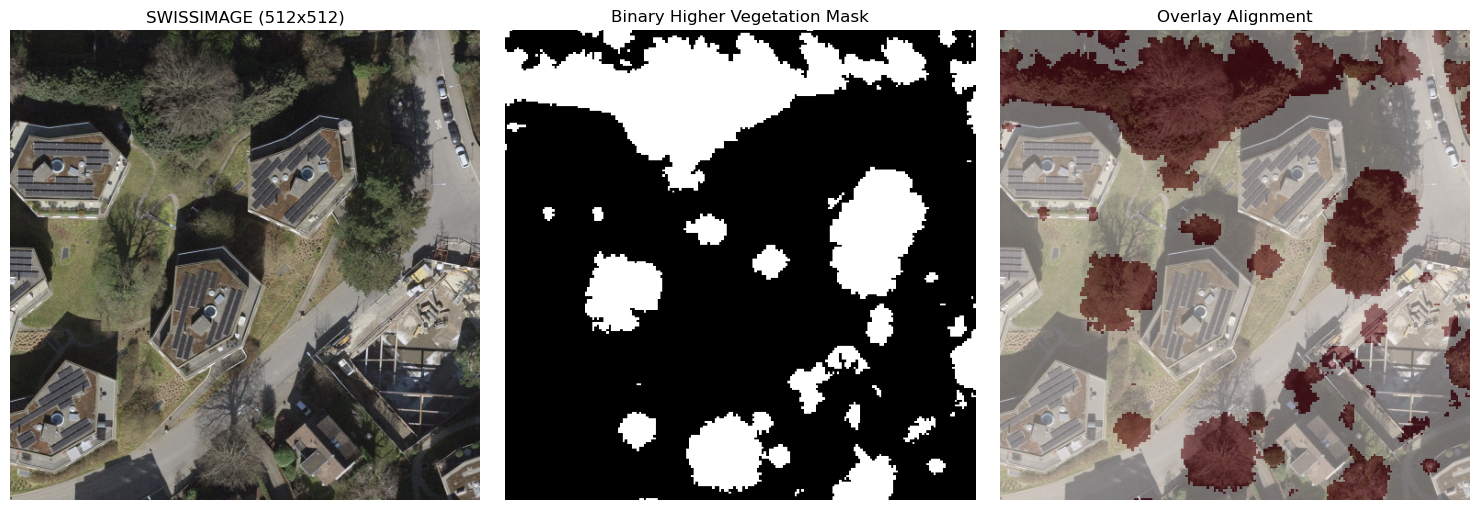

In [32]:
# Grab a random anchor from the training set
sample_row = gdf_anchors[gdf_anchors['split'] == 'train'].sample().iloc[0]
uid = sample_row['unique_id']

img_path = f"{BASE_OUT}/train/images/{uid}_swissimage.tif"
mask_path = f"{BASE_OUT}/train/{MASK_TASK_NAME}/{uid}_mask.tif"

if os.path.exists(img_path) and os.path.exists(mask_path):
    with rasterio.open(img_path) as src_img:
        # Swisstopo might return 3 (RGB) or 4 (RGBA) channels
        img = src_img.read()[:3] 
        # Convert from (C, H, W) to (H, W, C) for matplotlib
        img = np.moveaxis(img, 0, -1) 
        
    with rasterio.open(mask_path) as src_mask:
        mask = src_mask.read(1)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    axs[0].imshow(img)
    axs[0].set_title("SWISSIMAGE (512x512)")
    axs[0].axis("off")
    
    axs[1].imshow(mask, cmap="gray")
    axs[1].set_title("Binary Higher Vegetation Mask")
    axs[1].axis("off")
    
    # Overlay
    axs[2].imshow(img)
    axs[2].imshow(mask, cmap="Reds", alpha=0.4) # Overlay mask in semi-transparent red
    axs[2].set_title("Overlay Alignment")
    axs[2].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find both files for UID: {uid}. Ensure Notebook 1 ran successfully.")